In [1]:
# ============================================================
# CELL 1 - CÀI KAGGLE API & TẢI DỮ LIỆU
# ============================================================

# Cài thư viện cần thiết
!pip install kaggle imbalanced-learn -q

# Upload file kaggle.json (API key)
from google.colab import files
files.upload()  # Tải lên file kaggle.json từ máy tính

# Cấu hình kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Tải dataset CIC-IDS2017
!kaggle datasets download -d chethuhn/network-intrusion-dataset
!unzip -q network-intrusion-dataset.zip -d ./data
!ls ./data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:03<00:00, 69.8MB/s]

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [5]:
# ============================================================
# CELL ĐẦU TIÊN - KẾT NỐI GITHUB
# ============================================================

import os
from google.colab import userdata

# Cấu hình git
!git config --global user.email "nlhoanghoc@gmail.com"  # ← sửa
!git config --global user.name "Hoc273"               # ← sửa

# Clone repo về Colab
GITHUB_USER  = "Hoc273"          # ← sửa
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
REPO_NAME    = "Network-Intrusion-Detection--ML"

repo_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"

!git clone {repo_url}
%cd {REPO_NAME}

print("✅ Đã clone repo thành công")
!git status

Cloning into 'Network-Intrusion-Detection--ML'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 1), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 211.96 KiB | 7.07 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Network-Intrusion-Detection--ML/Network-Intrusion-Detection--ML
✅ Đã clone repo thành công
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [6]:
# ============================================================
# CELL 2 - KẾT NỐI GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Tạo thư mục lưu kết quả
import os
save_path = '/content/drive/MyDrive/IDS_Project/'
os.makedirs(save_path, exist_ok=True)
print(f"✅ Thư mục lưu: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Thư mục lưu: /content/drive/MyDrive/IDS_Project/


In [7]:
# ============================================================
# CELL 3 - KIỂM TRA TÀI NGUYÊN
# ============================================================

# Kiểm tra GPU
import torch
print("GPU:", torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "Không có GPU")

# Kiểm tra RAM
!cat /proc/meminfo | grep MemTotal

# Kiểm tra dung lượng disk
!df -h /content

GPU: Tesla T4
MemTotal:       13286948 kB
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   45G   69G  40% /


In [8]:
# ============================================================
# CELL 4 - CÀI ĐẶT THƯ VIỆN
# ============================================================

!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, glob, time, random, datetime
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import joblib

print("✅ Đã import tất cả thư viện")

✅ Đã import tất cả thư viện


In [ ]:
# ============================================================
# CELL 5- LOAD DỮ LIỆU (TỐI ƯU RAM)
# ============================================================
data_dir  = '/content/data/'
csv_files = glob.glob(data_dir + '**/*.csv', recursive=True)

print(f"Tìm thấy {len(csv_files)} file:")
for f in csv_files:
    print(f"  {os.path.basename(f)}")

Tìm thấy 8 file:
  Tuesday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [10]:
# ============================================================
# CELL 6 - ĐỌC TỪNG FILE (Tránh hết RAM)
# ============================================================

def load_and_clean_file(filepath):
    """Đọc 1 file CSV và làm sạch cơ bản ngay lập tức"""
    df = pd.read_csv(filepath, low_memory=False)

    # Xóa khoảng trắng tên cột
    df.columns = df.columns.str.strip()

    # Xử lý inf và NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Xóa hàng trùng lặp ngay
    df.drop_duplicates(inplace=True)

    # Downcast ngay để tiết kiệm RAM
    for col in df.select_dtypes(include=['int64','int32']).columns:
        df[col] = pd.to_numeric(df[col], downcast='unsigned')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')

    return df

# Load từng file và gộp lại
df_list = []
for i, f in enumerate(csv_files):
    print(f"[{i+1}/{len(csv_files)}] Đang load: {os.path.basename(f)}")
    temp = load_and_clean_file(f)
    df_list.append(temp)
    print(f"         Shape: {temp.shape}")

df = pd.concat(df_list, ignore_index=True)
del df_list  # Giải phóng RAM ngay
import gc; gc.collect()

print(f"\n✅ Tổng shape: {df.shape}")
print(f"RAM sử dụng: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")

[1/8] Đang load: Tuesday-WorkingHours.pcap_ISCX.csv
         Shape: (421844, 79)
[2/8] Đang load: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
         Shape: (164300, 79)
[3/8] Đang load: Monday-WorkingHours.pcap_ISCX.csv
         Shape: (502983, 79)
[4/8] Đang load: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
         Shape: (214114, 79)
[5/8] Đang load: Friday-WorkingHours-Morning.pcap_ISCX.csv
         Shape: (184145, 79)
[6/8] Đang load: Wednesday-workingHours.pcap_ISCX.csv
         Shape: (610794, 79)
[7/8] Đang load: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
         Shape: (252972, 79)
[8/8] Đang load: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
         Shape: (223112, 79)

✅ Tổng shape: (2574264, 79)
RAM sử dụng: 825.5 MB


In [11]:
# ============================================================
# CELL 7 - XỬ LÝ NaN & CHUẨN HÓA CỘT LABEL
# ============================================================

# Tìm đúng tên cột label
label_col = [c for c in df.columns
             if 'label' in c.lower()][0]
print(f"Cột nhãn: '{label_col}'")
print(df[label_col].value_counts())

# Thay NaN bằng median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Xóa cột phương sai = 0
zero_var = [c for c in num_cols if df[c].var() == 0]
df.drop(columns=zero_var, inplace=True)
print(f"\n✅ Đã xóa {len(zero_var)} cột zero-variance")
print(f"✅ Shape sau xử lý: {df.shape}")

Cột nhãn: 'Label'
Label
BENIGN                        2148386
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

✅ Đã xóa 8 cột zero-variance
✅ Shape sau xử lý: (2574264, 71)


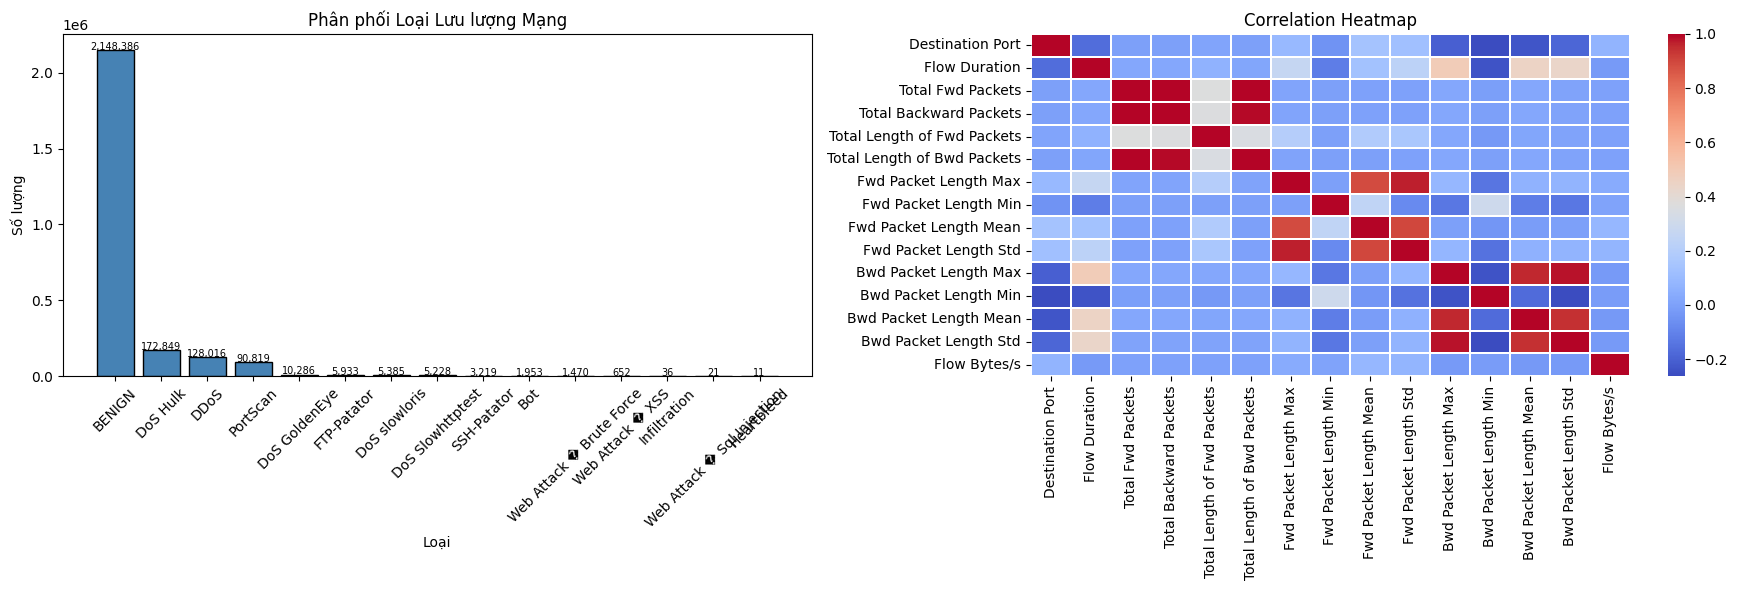

✅ Đã lưu eda_plots.png lên Drive và repo


In [12]:
# ============================================================
# CELL 8 - EDA: BIỂU ĐỒ PHÂN PHỐI
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Phân phối attack types
counts = df[label_col].value_counts()
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Phân phối Loại Lưu lượng Mạng')
axes[0].set_xlabel('Loại')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=45)
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 1000, f'{val:,}',
                 ha='center', fontsize=7)

# Biểu đồ 2: Correlation Heatmap (20 cột đầu)
sample_cols = df.select_dtypes(include=np.number).columns[:15]
corr = df[sample_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm',
            annot=False, linewidths=0.3)
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()

# Lưu lên Drive
plt.tight_layout()

# Lưu vào Google Drive (backup)
plt.savefig(save_path + 'eda_plots.png', dpi=150)

# Lưu vào repo để commit GitHub
plt.savefig('./outputs/eda_plots.png', dpi=150)

plt.show()
print("✅ Đã lưu eda_plots.png lên Drive và repo")

In [13]:
# --- Sau Bước EDA ---
# Lưu notebook trước
from google.colab import runtime  # không cần dùng, chỉ để nhắc nhở

# Copy file cần thiết vào repo
!cp /content/eda_plots.png ./outputs/
!cp /content/correlation_heatmap.png ./outputs/

!git add ./outputs/
!git commit -m "feat: EDA and data preprocessing"
!git push origin main
print("✅ Commit EDA xong")

cp: cannot stat '/content/eda_plots.png': No such file or directory
cp: cannot stat '/content/correlation_heatmap.png': No such file or directory
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✅ Commit EDA xong


In [14]:
# ============================================================
# CELL 9 - CHỌN ĐẶC TRƯNG & CHIA DỮ LIỆU
# ============================================================

selected_features = [
    'Destination Port',           # thay cho 'Protocol'
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'FIN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'URG Flag Count'
]

# Kiểm tra lại
available = [f for f in selected_features if f in df.columns]
missing   = [f for f in selected_features if f not in df.columns]
print(f"✅ Có: {len(available)}/18 đặc trưng")
if missing:
    print(f"⚠️  Thiếu: {missing}")
else:
    print("✅ Tất cả 18 đặc trưng đều khớp!")
X = df[available].copy()
y = df[label_col].copy()

# Mã hóa nhãn
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("\nMapping nhãn:")
for i, c in enumerate(le.classes_):
    print(f"  {i} ← {c}")

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Chuẩn hóa
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")

# # Giải phóng RAM
# del df; gc.collect()
# print("✅ Đã giải phóng RAM (xóa df gốc)")

✅ Có: 18/18 đặc trưng
✅ Tất cả 18 đặc trưng đều khớp!

Mapping nhãn:
  0 ← BENIGN
  1 ← Bot
  2 ← DDoS
  3 ← DoS GoldenEye
  4 ← DoS Hulk
  5 ← DoS Slowhttptest
  6 ← DoS slowloris
  7 ← FTP-Patator
  8 ← Heartbleed
  9 ← Infiltration
  10 ← PortScan
  11 ← SSH-Patator
  12 ← Web Attack � Brute Force
  13 ← Web Attack � Sql Injection
  14 ← Web Attack � XSS

✅ Train: (2059411, 18) | Test: (514853, 18)


In [15]:
# ============================================================
# CELL 9B (ĐẶT TRƯỚC CELL SMOTE) — Sample 20% stratified
# ============================================================
from sklearn.model_selection import train_test_split

SAMPLE_FRAC = 0.20   # 👈 Đổi tại đây: 0.10 / 0.20 / 0.30 / 0.50

print(f"⏳ Sampling {SAMPLE_FRAC*100:.0f}% dữ liệu (stratified)...")
print(f"   Trước: X_train={X_train_sc.shape}, y_train={y_train.shape}")

if SAMPLE_FRAC < 1.0:
    X_train_sc, _, y_train, _ = train_test_split(
        X_train_sc, y_train,
        train_size=SAMPLE_FRAC,
        stratify=y_train,          # ← giữ tỉ lệ từng class
        random_state=42
    )

print(f"   Sau : X_train={X_train_sc.shape}, y_train={y_train.shape}")
print(f"\n   Phân bố class sau sample:")
from collections import Counter
for code, count in sorted(Counter(y_train.tolist()).items()):
    print(f"   {le.classes_[code]:30s}: {count:,}")

⏳ Sampling 20% dữ liệu (stratified)...
   Trước: X_train=(2059411, 18), y_train=(2059411,)
   Sau : X_train=(411882, 18), y_train=(411882,)

   Phân bố class sau sample:
   BENIGN                        : 343,742
   Bot                           : 312
   DDoS                          : 20,483
   DoS GoldenEye                 : 1,646
   DoS Hulk                      : 27,656
   DoS Slowhttptest              : 836
   DoS slowloris                 : 862
   FTP-Patator                   : 949
   Heartbleed                    : 2
   Infiltration                  : 6
   PortScan                      : 14,531
   SSH-Patator                   : 515
   Web Attack � Brute Force      : 235
   Web Attack � Sql Injection    : 3
   Web Attack � XSS              : 104


In [16]:
# # Giải phóng RAM
del df; gc.collect()
print("✅ Đã giải phóng RAM (xóa df gốc)")

✅ Đã giải phóng RAM (xóa df gốc)


In [26]:
# Kiểm tra tên cột thật trong dataset
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packe

In [17]:
# ============================================================
# CELL 10 — SMOTE + RandomUnderSampler (FIX ValueError)
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

print("Phân bố TRƯỚC khi cân bằng:")
counter = Counter(y_train.tolist())
for code, count in sorted(counter.items()):
    print(f"  {le.classes_[code]:35s}: {count:,}")

majority_count  = max(counter.values())
min_count       = min(counter.values())

# ── Ngưỡng SMOTE: 10% majority, nhưng không nhỏ hơn min_count ──
target_minority = max(min_count, int(majority_count * 0.10))
print(f"\nNgưỡng target minority : {target_minority:,}")

# ── k_neighbors an toàn: nhỏ hơn số mẫu ít nhất của 1 class ──
# SMOTE cần: k_neighbors < số mẫu của class đó
safe_k = max(1, min_count - 1)   # ← FIX chính: tự động điều chỉnh k
print(f"k_neighbors an toàn    : {safe_k}")

# ── Chỉ upsample class nào CÓ ĐỦ mẫu để SMOTE hoạt động ──────
# Class có < (safe_k + 1) mẫu sẽ bị bỏ qua hoặc dùng random oversampling
smote_strategy = {}
skip_classes   = []

for code, count in counter.items():
    if count < target_minority:
        if count > safe_k:           # đủ mẫu để SMOTE
            smote_strategy[code] = target_minority
        else:                        # quá ít → bỏ qua, xử lý riêng
            skip_classes.append((le.classes_[code], count))

print(f"\nClass sẽ upsample bằng SMOTE : {len(smote_strategy)}")
if skip_classes:
    print(f"Class bỏ qua (quá ít mẫu)   : {len(skip_classes)}")
    for name, cnt in skip_classes:
        print(f"  ⚠️  {name}: chỉ có {cnt} mẫu")

# ── SMOTE chỉ chạy nếu có class cần upsample ─────────────────
steps = []

if smote_strategy:
    steps.append(('smote', SMOTE(
        sampling_strategy=smote_strategy,
        k_neighbors=safe_k,
        random_state=42
    )))

# RandomUnderSampler: giảm BENIGN
benign_code    = le.transform(['BENIGN'])[0]
under_strategy = {benign_code: target_minority * 3}

steps.append(('under', RandomUnderSampler(
    sampling_strategy=under_strategy,
    random_state=42
)))

pipeline_bal = Pipeline(steps)
X_bal, y_bal = pipeline_bal.fit_resample(X_train_sc, y_train)

print(f"\n✅ Shape sau cân bằng: {X_bal.shape}")
print("\nPhân bố SAU khi cân bằng:")
counter2 = Counter(y_bal.tolist())
for code, count in sorted(counter2.items()):
    print(f"  {le.classes_[code]:35s}: {count:,}")

Phân bố TRƯỚC khi cân bằng:
  BENIGN                             : 343,742
  Bot                                : 312
  DDoS                               : 20,483
  DoS GoldenEye                      : 1,646
  DoS Hulk                           : 27,656
  DoS Slowhttptest                   : 836
  DoS slowloris                      : 862
  FTP-Patator                        : 949
  Heartbleed                         : 2
  Infiltration                       : 6
  PortScan                           : 14,531
  SSH-Patator                        : 515
  Web Attack � Brute Force           : 235
  Web Attack � Sql Injection         : 3
  Web Attack � XSS                   : 104

Ngưỡng target minority : 34,374
k_neighbors an toàn    : 1

Class sẽ upsample bằng SMOTE : 14

✅ Shape sau cân bằng: (584358, 18)

Phân bố SAU khi cân bằng:
  BENIGN                             : 103,122
  Bot                                : 34,374
  DDoS                               : 34,374
  DoS GoldenEye      

In [18]:
# --- Sau Bước Xử lý Imbalance ---
!git commit --allow-empty -m "feat: handle class imbalance with SMOTE"
!git push origin main
print("✅ Commit SMOTE xong")

[main 1a64ba2] feat: handle class imbalance with SMOTE
Enumerating objects: 1, done.
Counting objects: 100% (1/1), done.
Writing objects: 100% (1/1), 209 bytes | 209.00 KiB/s, done.
Total 1 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Hoc273/Network-Intrusion-Detection--ML.git
   dfee871..1a64ba2  main -> main
✅ Commit SMOTE xong


In [19]:
# ============================================================
# CELL 11 — HUẤN LUYỆN 5 MÔ HÌNH (KNN dùng tập riêng nhỏ hơn)
# ============================================================
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                             precision_score, recall_score, f1_score)

# ── Tạo tập nhỏ riêng cho KNN ────────────────────────────────
# KNN không cần nhiều data, 5000 mẫu/class là đủ tốt
KNN_MAX_PER_CLASS = 5000

idx_knn = []
for cls in np.unique(y_bal):
    cls_idx = np.where(y_bal == cls)[0]
    chosen  = cls_idx[:KNN_MAX_PER_CLASS]   # lấy tối đa 5000/class
    idx_knn.extend(chosen)

idx_knn  = np.array(idx_knn)
X_bal_knn = X_bal[idx_knn]
y_bal_knn = y_bal[idx_knn]

print(f"X_bal đầy đủ : {X_bal.shape}")
print(f"X_bal KNN    : {X_bal_knn.shape}  ← KNN sẽ dùng tập này")

# ── Định nghĩa models ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=200, solver='saga', random_state=42, n_jobs=-1
    ),
    'SVM (Linear)': LinearSVC(
        max_iter=500, C=0.1, random_state=42
    ),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(
        n_neighbors=3,
        algorithm='ball_tree',
        leaf_size=50,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=50, max_depth=20,
        min_samples_leaf=4, random_state=42, n_jobs=-1
    ),
}

results        = {}
trained_models = {}
total          = len(models)

for i, (name, model) in enumerate(models.items(), 1):
    sep = '─' * 50
    print(f'\n{sep}')
    print(f'({i}/{total})  {name}')
    print(sep)

    # ── Chọn tập train phù hợp ───────────────────────────────
    if name == 'KNN':
        X_train_use = X_bal_knn
        y_train_use = y_bal_knn
        print(f'  ⚡ Dùng tập nhỏ: {X_bal_knn.shape[0]:,} mẫu')
    else:
        X_train_use = X_bal
        y_train_use = y_bal

    # ── Train ────────────────────────────────────────────────
    t0 = time.time()
    model.fit(X_train_use, y_train_use)
    train_time = time.time() - t0

    # ── Predict ──────────────────────────────────────────────
    t1 = time.time()
    y_pred = model.predict(X_test_sc)
    pred_time = time.time() - t1

    # ── Metrics ──────────────────────────────────────────────
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

    results[name] = {
        'accuracy':   acc,
        'precision':  prec,
        'recall':     rec,
        'f1':         f1,
        'train_time': train_time,
        'pred_time':  pred_time,
        'y_pred':     y_pred,
    }
    trained_models[name] = model

    print(f'  ⏱  Train: {train_time:.1f}s  |  Predict: {pred_time:.1f}s')
    print(f'  🎯 Accuracy : {acc*100:.2f}%')
    print(f'  📐 F1-score : {f1*100:.2f}%')
    print(classification_report(
        y_test, y_pred,
        target_names=le.classes_,
        zero_division=0
    ))

# ── Lưu model tốt nhất theo F1 ───────────────────────────────
best_name  = max(results, key=lambda k: results[k]['f1'])
best_model = trained_models[best_name]
joblib.dump(best_model, 'best_model.pkl')

total_time = sum(v['train_time'] + v['pred_time'] for v in results.values())
print(f'\n{"="*50}')
print(f'🏆  Best model     : {best_name}')
print(f'📐  F1-score       : {results[best_name]["f1"]*100:.2f}%')
print(f'⏱   Tổng thời gian : {total_time:.1f}s')
print(f'💾  Đã lưu         : best_model.pkl')

X_bal đầy đủ : (584358, 18)
X_bal KNN    : (75000, 18)  ← KNN sẽ dùng tập này

──────────────────────────────────────────────────
(1/5)  Logistic Regression
──────────────────────────────────────────────────
  ⏱  Train: 219.2s  |  Predict: 0.1s
  🎯 Accuracy : 66.71%
  📐 F1-score : 76.15%
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.62      0.76    429677
                       Bot       0.01      0.71      0.02       391
                      DDoS       0.53      0.94      0.67     25603
             DoS GoldenEye       0.26      0.81      0.39      2057
                  DoS Hulk       0.87      0.92      0.90     34570
          DoS Slowhttptest       0.04      0.80      0.07      1046
             DoS slowloris       0.26      0.55      0.35      1077
               FTP-Patator       0.06      0.31      0.10      1187
                Heartbleed       0.04      1.00      0.07         2
              Infiltration    

In [22]:
!git add ./outputs/
!git commit -m "feat: train and compare 5 ML models"
!git push origin main
print("✅ Commit mô hình xong")

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✅ Commit mô hình xong


In [33]:
# ============================================================
# CELL 12 - LƯU MÔ HÌNH LÊN DRIVE
# ============================================================

os.makedirs('./models', exist_ok=True)  # ← thêm dòng này
# Lưu lên Drive
joblib.dump(trained_models['Random Forest'],
            save_path + 'random_forest_ids.pkl')
joblib.dump(scaler, save_path + 'scaler.pkl')
joblib.dump(le,     save_path + 'label_encoder.pkl')
print("✅ Đã lưu model lên Drive")

# Kiểm tra kích thước
size_mb = os.path.getsize(
    save_path + 'random_forest_ids.pkl') / 1024**2
print(f"Kích thước model: {size_mb:.1f} MB")

if size_mb < 100:
    !cp {save_path}*.pkl ./models/
    !git add ./models/
    !git commit -m "feat: save trained Random Forest model"
    !git push origin main
    print("✅ Đã commit model lên GitHub")
else:
    print("⚠️  Model > 100MB → Thêm Google Drive link vào README")



✅ Đã lưu model lên Drive
Kích thước model: 14.0 MB
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✅ Đã commit model lên GitHub


In [34]:
!git commit --allow-empty -m "feat: save models to Google Drive"
!git push origin main

[main 4705063] feat: save models to Google Drive
Enumerating objects: 1, done.
Counting objects: 100% (1/1), done.
Writing objects: 100% (1/1), 197 bytes | 197.00 KiB/s, done.
Total 1 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Hoc273/Network-Intrusion-Detection--ML.git
   bb33901..4705063  main -> main


In [30]:
# ============================================================
# CELL 13 - REAL-TIME DETECTION & ALERT
# ============================================================
import os

rf_model = joblib.load(save_path + 'random_forest_ids.pkl')
sc       = joblib.load(save_path + 'scaler.pkl')
lb_enc   = joblib.load(save_path + 'label_encoder.pkl')
os.makedirs('./logs', exist_ok=True)
def detect_intrusion(flow_input: dict) -> str:
    os.makedirs('./logs', exist_ok=True)
    input_df = pd.DataFrame([flow_input])[available]
    input_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    input_df.fillna(0, inplace=True)
    scaled = sc.transform(input_df)
    pred   = rf_model.predict(scaled)[0]
    label  = lb_enc.inverse_transform([pred])[0]
    proba  = rf_model.predict_proba(scaled)[0].max()
    ts     = datetime.datetime.now().strftime("%Y-%m-%dT%H:%M:%S")

    if label.upper() != 'BENIGN':
        alert = (f"[{ts}] [ALERT] Suspicious traffic detected: "
                 f"{label}. Confidence: {proba*100:.1f}%")
        print(f"\033[91m{alert}\033[0m")
        with open('./logs/alerts.log', 'a') as f:
            f.write(alert + '\n')
        with open(save_path + 'alerts.log', 'a') as f:
            f.write(alert + '\n')
    else:
        print(f"[{ts}] ✅ BENIGN — Confidence: {proba*100:.1f}%")
    return label

# Test 10 mẫu ngẫu nhiên
print("="*55)
print("🚀 MÔ PHỎNG PHÁT HIỆN XÂM NHẬP THỜI GIAN THỰC")
print("="*55)
for i in range(10):
    idx  = random.randint(0, len(X_test)-1)
    flow = dict(zip(available, X_test.iloc[idx].values))
    true = lb_enc.inverse_transform([y_test[idx]])[0]
    print(f"\n--- Mẫu #{i+1} | Nhãn thực: [{true}] ---")
    detect_intrusion(flow)

🚀 MÔ PHỎNG PHÁT HIỆN XÂM NHẬP THỜI GIAN THỰC

--- Mẫu #1 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 100.0%

--- Mẫu #2 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 100.0%

--- Mẫu #3 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 66.7%

--- Mẫu #4 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 100.0%

--- Mẫu #5 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 99.5%

--- Mẫu #6 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 100.0%

--- Mẫu #7 | Nhãn thực: [DoS Hulk] ---
[2026-05-01T09:13:42] [ALERT] Suspicious traffic detected: DoS Hulk. Confidence: 100.0%

--- Mẫu #8 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 97.9%

--- Mẫu #9 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 100.0%

--- Mẫu #10 | Nhãn thực: [BENIGN] ---
[2026-05-01T09:13:42] ✅ BENIGN — Confidence: 100.0%


In [31]:
!git add ./logs/
!git commit -m "feat: real-time intrusion detection and alert generation"
!git push origin main
print("\n✅ Commit real-time detection xong")

[main bb33901] feat: real-time intrusion detection and alert generation
 1 file changed, 1 insertion(+)
 create mode 100644 logs/alerts.log
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 468 bytes | 234.00 KiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Hoc273/Network-Intrusion-Detection--ML.git
   f653bc9..bb33901  main -> main

✅ Commit real-time detection xong



📊 BẢNG SO SÁNH 5 MÔ HÌNH
              Model Accuracy Precision Recall F1-Score Time (s)
Logistic Regression   66.71%    94.38% 66.71%   76.15%    219.2
       SVM (Linear)   73.78%    94.52% 73.78%   81.30%    225.5
        Naive Bayes   36.27%    96.62% 36.27%   49.72%      0.3
                KNN   94.23%    97.67% 94.23%   95.60%      0.2
      Random Forest   98.51%    99.66% 98.51%   99.03%     36.1


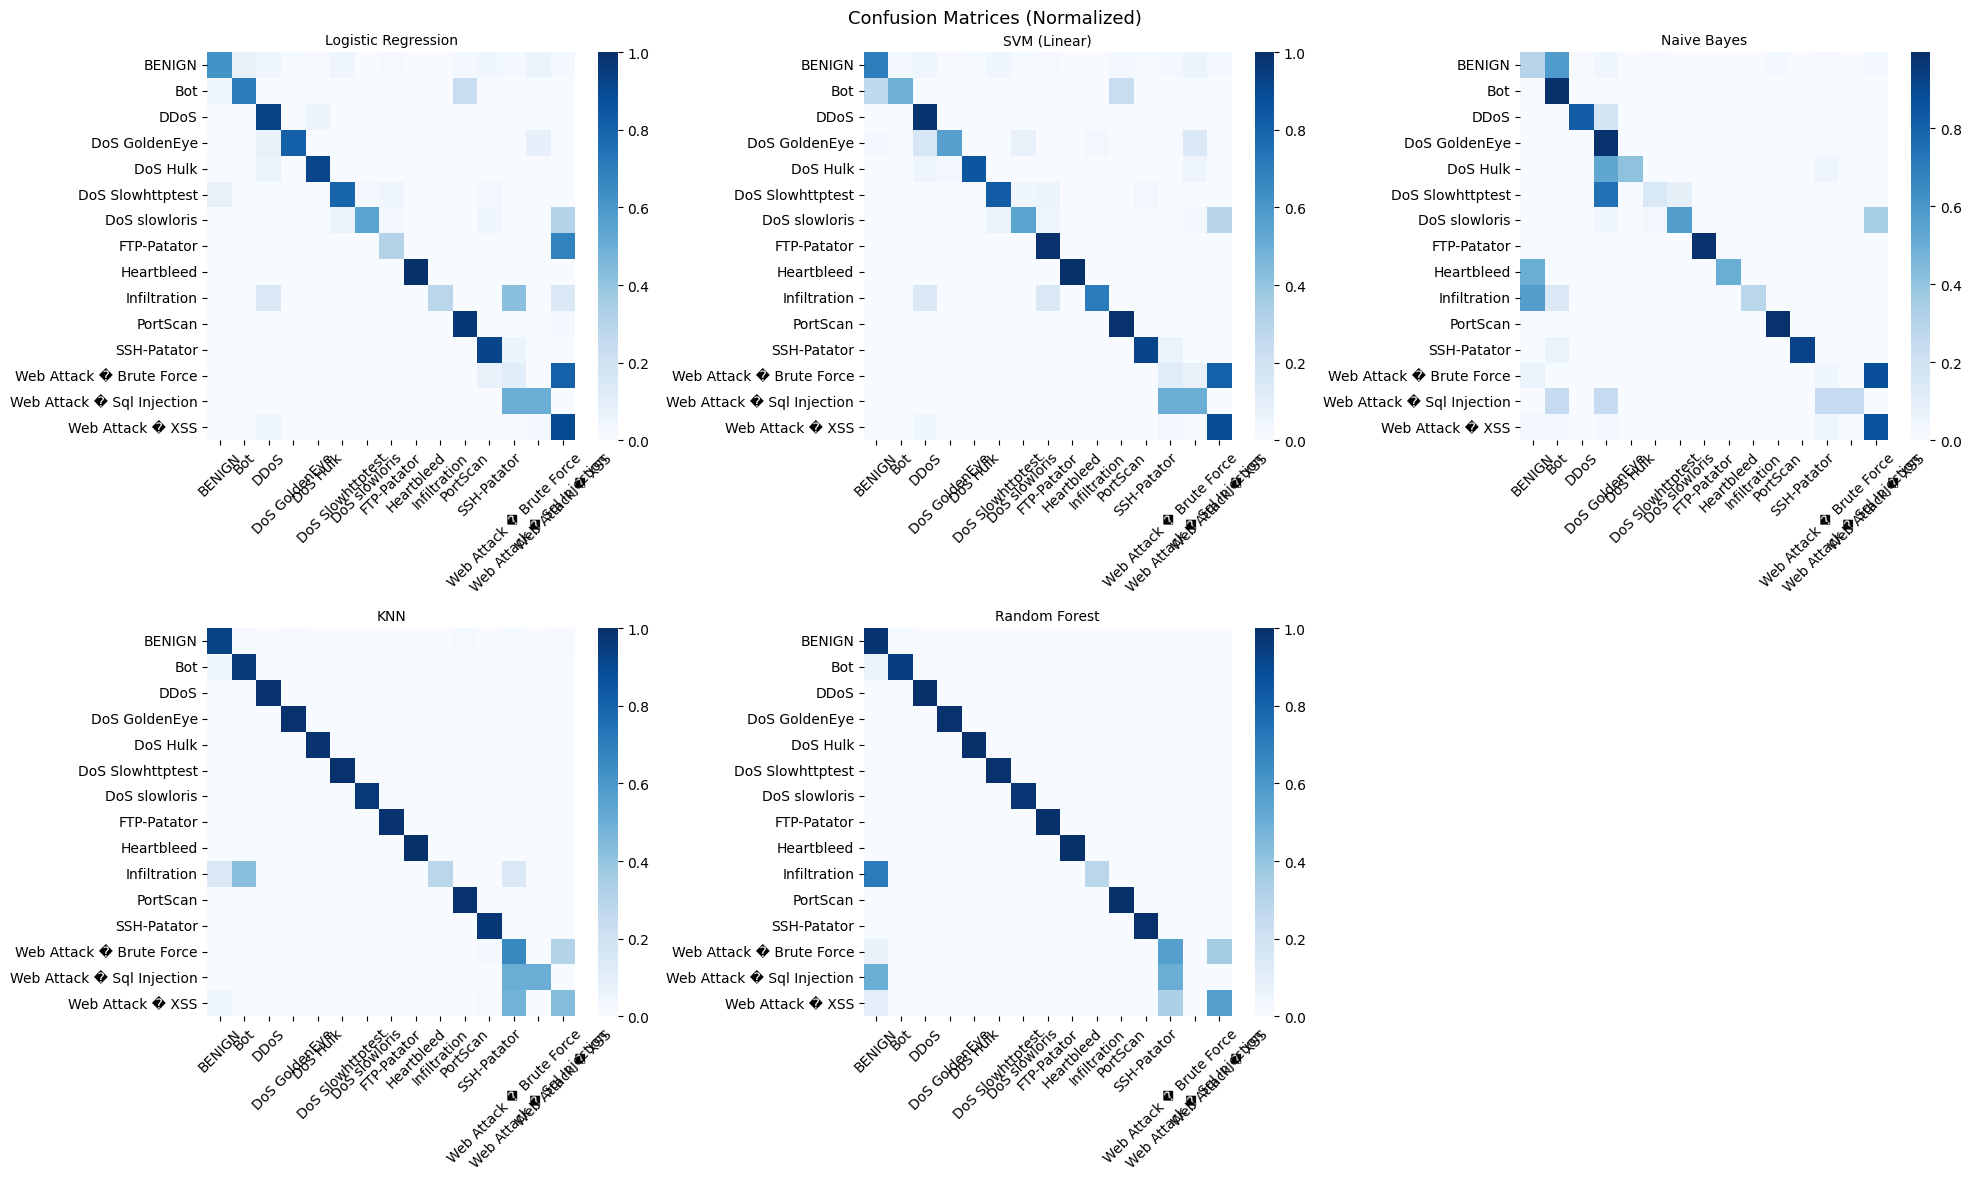

✅ Xong!


In [35]:
# ============================================================
# CELL 14 - BẢNG SO SÁNH & VẼ CONFUSION MATRIX
# ============================================================

# Bảng so sánh
rows = []
for name, res in results.items():
    rows.append({
        'Model':     name,
        'Accuracy':  f"{res['accuracy']*100:.2f}%",
        'Precision': f"{res['precision']*100:.2f}%",
        'Recall':    f"{res['recall']*100:.2f}%",
        'F1-Score':  f"{res['f1']*100:.2f}%",
        'Time (s)':  f"{res['train_time']:.1f}"
    })

cmp_df = pd.DataFrame(rows)
print("\n📊 BẢNG SO SÁNH 5 MÔ HÌNH")
print(cmp_df.to_string(index=False))
cmp_df.to_csv('./outputs/model_comparison.csv', index=False)
cmp_df.to_csv(save_path + 'model_comparison.csv', index=False)

# Confusion Matrices
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_n, ax=axes[i], cmap='Blues', annot=False,
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(name, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices (Normalized)', fontsize=13)
plt.tight_layout()
plt.savefig('./outputs/confusion_matrices.png', dpi=150)
plt.savefig(save_path + 'confusion_matrices.png', dpi=150)
plt.show()
print("✅ Xong!")

In [36]:
!git add ./outputs/
!git commit -m "feat: BẢNG SO SÁNH & VẼ CONFUSION MATRIX"
!git push origin main
print("✅ Commit mô hình xong")

[main 1131d3d] feat: BẢNG SO SÁNH & VẼ CONFUSION MATRIX
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 outputs/confusion_matrices.png
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 257.75 KiB | 12.89 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Hoc273/Network-Intrusion-Detection--ML.git
   4705063..1131d3d  main -> main
✅ Commit mô hình xong


In [8]:
# Tạo cấu trúc thư mục chuẩn
!mkdir -p notebooks outputs models logs

# Tạo .gitignore
gitignore_content = """
# Data (quá lớn, không commit)
data/
*.csv

# Model lớn
*.pkl

# Jupyter checkpoints
.ipynb_checkpoints/
__pycache__/

# Colab temp
*.pyc
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore_content)

print("✅ Đã tạo cấu trúc thư mục")
!ls -la

✅ Đã tạo cấu trúc thư mục
total 32
drwxr-xr-x 7 root root 4096 May  1 04:34 .
drwxr-xr-x 1 root root 4096 May  1 04:26 ..
drwxr-xr-x 7 root root 4096 May  1 04:26 .git
-rw-r--r-- 1 root root  145 May  1 04:34 .gitignore
drwxr-xr-x 2 root root 4096 May  1 04:34 logs
drwxr-xr-x 2 root root 4096 May  1 04:34 models
drwxr-xr-x 2 root root 4096 May  1 04:34 notebooks
drwxr-xr-x 2 root root 4096 May  1 04:34 outputs
